In [1]:
import scanpy as sc
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import seaborn as sns

In [3]:
from scipy import sparse
from scipy.stats import entropy, spearmanr, mannwhitneyu, fisher_exact, probplot, kruskal
from scipy.spatial import cKDTree

# H&E image

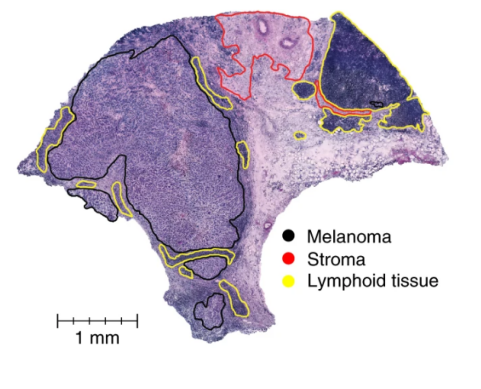

In [4]:
img = mpimg.imread("/scratch/lalonsoeste/PhD/SpatialTranscriptomics/data/spatial/BayesSpace/melanoma_thrane/processed/melanoma_rep1.png")

plt.imshow(img)
plt.axis("off")   # hides axes
plt.show()

# Load data (K=4 )

In [5]:
adata = sc.read_h5ad("/scratch/lalonsoeste/PhD/SpatialTranscriptomics/data/spatial/BayesSpace/melanoma_thrane/processed/ST_mel1_rep2.h5ad")
adata.var_names_make_unique()

sc.pp.filter_genes(adata, min_counts=11)

adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
adata.layers["norm"] = adata.X.copy()
sc.pp.log1p(adata)
adata.layers["lognorm"] = adata.X.copy()

adata

/scratch/lalonsoeste/envs/ST/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 293 × 10942
    obs: 'array_row', 'array_col', 'array_col_flipped'
    var: 'gene_id', 'ensemble_id', 'n_counts'
    uns: 'log1p'
    obsm: 'spatial'
    layers: 'counts', 'norm', 'lognorm'

In [6]:
SIGNATURES = {
    "Tumor cells (surrounding)": ["CXCL10","WARS1","C1QB","GBP4","CXCL9"],
    "Tumor cells (center)": ["SPP1","HSPB1","ATP1A1","NDRG1","ANXA1"],
    "Stroma": ["MYL9","CFD","DCN","COL3A1","CH507-513H4.5"],
    "Lymphoid": ["LTB","CD79A","MS4A1","CCL21","CD79B"],
}

In [7]:
K=4

## Proportions ($H$)

In [8]:
snmf_proportions = pd.read_csv(f"./K{K}/SNMF_proportions.csv", index_col=0)
snmf_proportions

,V1,V2,V3,V4
7x15,0.273434,0.074859,0.197405,0.454302
7x16,0.214527,0.221338,0.244813,0.319322
7x17,0.113882,0.402638,0.329447,0.154032
7x18,0.105490,0.542102,0.224054,0.128354
8x13,0.096841,0.157761,0.337943,0.407454
...,...,...,...,...
27x18,0.000398,0.508507,0.263692,0.227403
27x19,0.002746,0.511701,0.174788,0.310764
27x20,0.000486,0.306713,0.550300,0.142501
27x21,0.000172,0.046386,0.811832,0.141610


In [9]:
adata.obs = pd.concat([adata.obs, snmf_proportions], axis=1)

## Signatures ($W$)

In [10]:
snmf_signatures = pd.read_csv(f"./K{K}/signatures.csv", index_col=0)
snmf_signatures

,V1,V2,V3,V4
PSME2,2.525697,3.402686,4.120987,15.210362
CUEDC1,0.737316,0.464159,0.175260,0.473928
RPLP1,49.104212,208.518677,89.693282,34.965165
TM9SF3,1.698330,0.774840,1.797161,1.880539
DEF8,1.259931,2.311966,1.620939,1.216029
...,...,...,...,...
MICU3,0.000001,0.330808,0.213525,0.000001
CTAGE5,0.025709,0.181829,0.229819,0.000001
ALPL,0.000001,0.000002,0.411979,0.000001
GPC3,0.000001,0.000002,0.514976,0.000001


In [11]:
adata.var = pd.concat([adata.var, snmf_signatures], axis=1)

## Dispersion parameters ($\phi, \alpha, \beta$)

In [12]:
phi = pd.read_csv(f"./K{K}/phi.csv", index_col=0).T.loc[adata.obs_names, adata.var_names]
alpha = pd.read_csv(f"./K{K}/alpha.csv", index_col=0).T.loc[adata.var_names].values
beta = pd.read_csv(f"./K{K}/beta.csv", index_col=0).T.loc[adata.obs_names].values

adata.var["alpha_dispersion"] = alpha
adata.obs["beta_dispersion"] = beta

adata.layers["phi"] = phi
adata.layers["theta"] = 1 / phi

## Spatial filtering matrix $S$

In [13]:
TAU = 0.8

In [14]:
from scipy.spatial.distance import cdist
from scipy.optimize import minimize

positions = np.array(adata.obs_names.str.split("x").tolist()).astype(float)

x = positions[:, 0]
y = positions[:, 1]

def mean_value(gamma, x, y, tau):
    gamma = gamma[0] if np.ndim(gamma) else gamma

    # Pairwise squared Euclidean distances
    coords = np.column_stack((x, y))
    D2 = cdist(coords, coords, metric='sqeuclidean')

    # Similarity matrix
    S = np.exp(-gamma * D2)
    S[S < 1e-3] = 0

    # Row normalization
    row_sums = S.sum(axis=1, keepdims=True)
    S = S / row_sums

    # Objective function
    return (np.mean(np.diag(S)) - tau) ** 2

# Optimize gamma
result = minimize(
    mean_value,
    x0=[1.0],
    args=(x, y, TAU),
    method="BFGS"
)

gamma = result.x[0]

# Compute final normalized similarity matrix
coords = np.column_stack((x, y))
D2 = cdist(coords, coords, metric='sqeuclidean')

S = np.exp(-gamma * D2)
S[S < 1e-3] = 0

row_sums = S.sum(axis=1, keepdims=True)
S = S / row_sums

## Inferred matrix $V$

In [107]:
V = (snmf_signatures.values @ snmf_proportions.values.T @ S).T
adata.X = V

adata.layers["inferred_counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
adata.layers["inferred_norm"] = adata.X.copy()
sc.pp.log1p(adata)
adata.layers["inferred_lognorm"] = adata.X.copy()

# Functions

In [16]:
def valid_genes(genes):
    return [g for g in genes if g in adata.var_names]

def add_expr_score(genes, key):
    genes = valid_genes(genes)
    X = adata[:, genes].X
    vals = X.mean(axis=1)
    adata.obs[key] = vals
    return genes

def add_phi_score(genes, key):
    genes = [g for g in genes if g in phi.columns]
    adata.obs[key] = phi[genes].mean(axis=1)
    return genes

def zscore(s):
    s = pd.Series(s).astype(float)
    sd = s.std()
    return (s - s.mean()) / (sd if sd and not np.isnan(sd) else 1.0)

def compare_by_mask(value_key, mask):
    x = adata.obs.loc[mask, value_key].dropna()
    y = adata.obs.loc[~mask, value_key].dropna()
    p = mannwhitneyu(x, y, alternative="two-sided").pvalue if len(x) and len(y) else np.nan
    return pd.Series({
        "feature": value_key,
        "in_median": x.median(),
        "out_median": y.median(),
        "p": p,
        "n_in": len(x),
        "n_other": len(y),
    })

# Annotation

In [17]:
import numpy as np

snmf_z = (snmf_signatures - snmf_signatures.mean(axis=0)) / snmf_signatures.std(axis=0)

score_table = pd.DataFrame(index=SIGNATURES.keys(),
                           columns=snmf_z.columns,
                           dtype=float)

for comp in snmf_z.columns:
    for celltype, markers in SIGNATURES.items():
        valid = [g for g in markers if g in snmf_z.index]
        if len(valid) > 0:
            score_table.loc[celltype, comp] = (
                snmf_z.loc[valid, comp].mean() - snmf_z[comp].mean()
            )
        else:
            score_table.loc[celltype, comp] = -np.inf

# --------------------------------------------------
# 2️⃣ Annotation function
# --------------------------------------------------
def unique_assignment(score_table, threshold=0.2):
    
    # For each component, sort cell types by descending score
    ranked = {
        comp: score_table[comp].sort_values(ascending=False).index.tolist()
        for comp in score_table.columns
    }
    
    assigned_celltypes = set()
    final_assignment = {}
    
    # Sort components by their BEST score (descending)
    components_order = sorted(
        score_table.columns,
        key=lambda c: score_table[c].max(),
        reverse=True
    )
    
    for comp in components_order:
        for celltype in ranked[comp]:
            
            if score_table.loc[celltype, comp] < threshold:
                final_assignment[comp] = "ambiguous"
                break
            
            if celltype not in assigned_celltypes:
                final_assignment[comp] = celltype
                assigned_celltypes.add(celltype)
                break
        else:
            final_assignment[comp] = "ambiguous"
    
    return pd.Series(final_assignment)

# --------------------------------------------------
# 3️⃣ Apply to all components
# --------------------------------------------------
annotation = unique_assignment(score_table)

print(annotation)

V1         Tumor cells (center)
V2                       Stroma
V4    Tumor cells (surrounding)
V3                     Lymphoid
dtype: object


In [18]:
N_TOP_GENES = 5

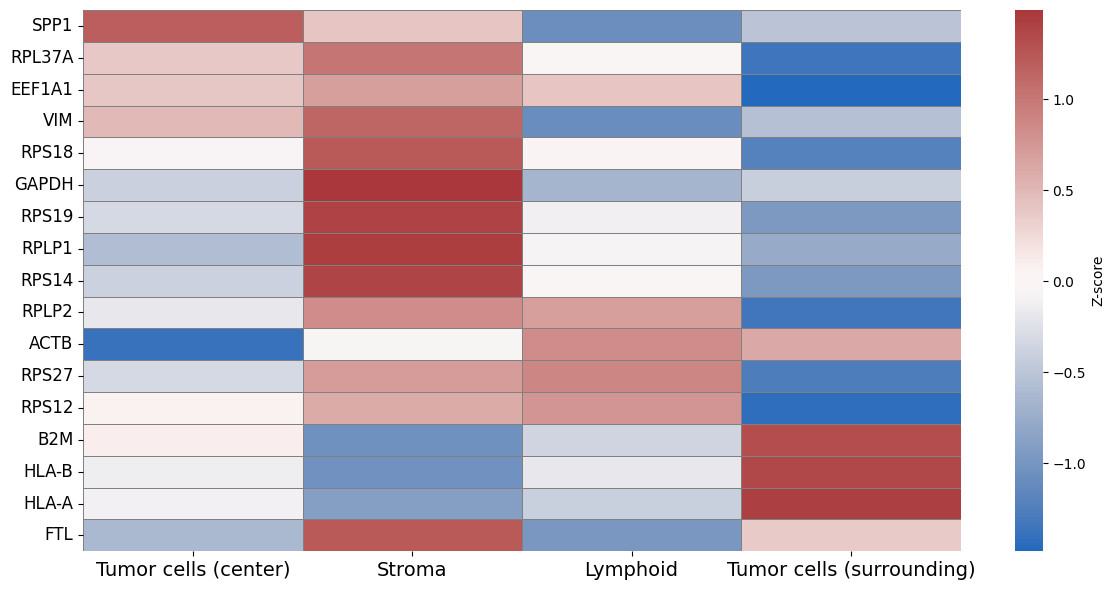

In [19]:
top_genes_ordered = []
for comp in snmf_signatures.columns:
    top_genes = snmf_signatures[comp].sort_values(ascending=False).head(N_TOP_GENES).index
    top_genes_ordered.extend([g for g in top_genes if g not in top_genes_ordered])

# Subset and reorder genes
snmf_top = snmf_signatures.loc[top_genes_ordered]

# ----- 2️⃣ Scale genes (row-wise z-score) -----
snmf_scaled = snmf_top.sub(snmf_top.mean(axis=1), axis=0).div(snmf_top.std(axis=1), axis=0)

# ----- 3️⃣ Fancy heatmap with Seaborn -----
plt.figure(figsize=(12, max(6, len(top_genes_ordered) * 0.25)))

# sns.set_style("white")
# sns.set_context("talk")

# Optionally, order components by annotation or clustering
sns.heatmap(
    snmf_scaled,
    cmap="vlag",          # diverging colormap for z-scores
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Z-score"},
    xticklabels=[annotation.get(c, c) for c in snmf_scaled.columns],
    yticklabels=snmf_scaled.index
)

plt.xticks(fontsize=14)
plt.yticks(rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig(f"plots/K{K}_top_genes_heatmap.png", dpi=300)
plt.savefig(f"plots/K{K}_top_genes_heatmap.pdf", dpi=300)
plt.show()

In [20]:
for comp in snmf_signatures.columns:
    top_genes = snmf_signatures[comp].sort_values(ascending=False).head(N_TOP_GENES).index
    print(f"{annotation[comp]} variance: {snmf_scaled.loc[top_genes,comp].var()}")
    print(f"{annotation[comp]} range: {snmf_scaled.loc[top_genes,comp].max() - snmf_scaled.loc[top_genes,comp].min()}")
    print(f"{annotation[comp]} mean: {snmf_scaled.loc[top_genes,comp].mean()}")
    print()

Tumor cells (center) variance: 0.19959900459439317
Tumor cells (center) range: 1.2367056417202629
Tumor cells (center) mean: 0.48116135074842586

Stroma variance: 0.009766460911734887
Stroma range: 0.2642799928223738
Stroma mean: 1.3877878105503563

Lymphoid variance: 0.03582384899103049
Lymphoid range: 0.47849786276146833
Lymphoid mean: 0.7150376246601223

Tumor cells (surrounding) variance: 0.24064371424882774
Tumor cells (surrounding) range: 1.0520197052073708
Tumor cells (surrounding) mean: 1.0183456585420427



In [21]:
adata.obs.columns = [c if c not in annotation.index.tolist() else annotation[c] for c in adata.obs.columns]
adata.var.columns = [c if c not in annotation.index.tolist() else annotation[c] for c in adata.var.columns]

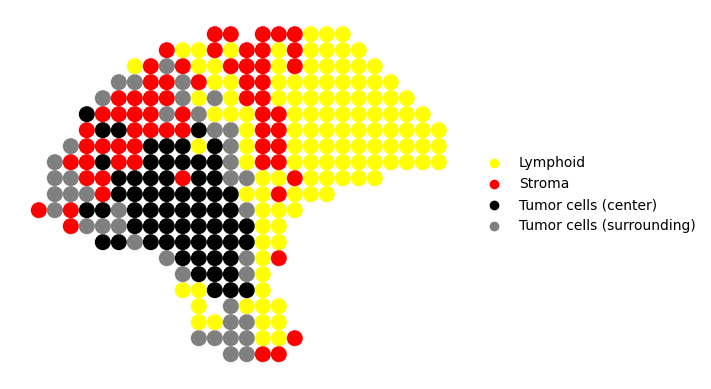

In [22]:
adata.obs["snmf_component"] = adata.obs[[annotation[c] for c in snmf_signatures.columns]].idxmax(axis=1)

PALETTE = {
    "Stroma": "red",
    "Lymphoid": "yellow",
    "Tumor cells (center)": "black",
    "Tumor cells (surrounding)": "gray",
}

sc.pl.spatial(
    adata,
    color="snmf_component",
    palette=PALETTE,
    spot_size=1,
    frameon=False,
    title="",
    show=False,
)

plt.savefig(f"plots/K{K}_clustering.png", dpi=300)
plt.savefig(f"plots/K{K}_clustering.pdf", dpi=300)
plt.show()

<Figure size 1400x600 with 0 Axes>

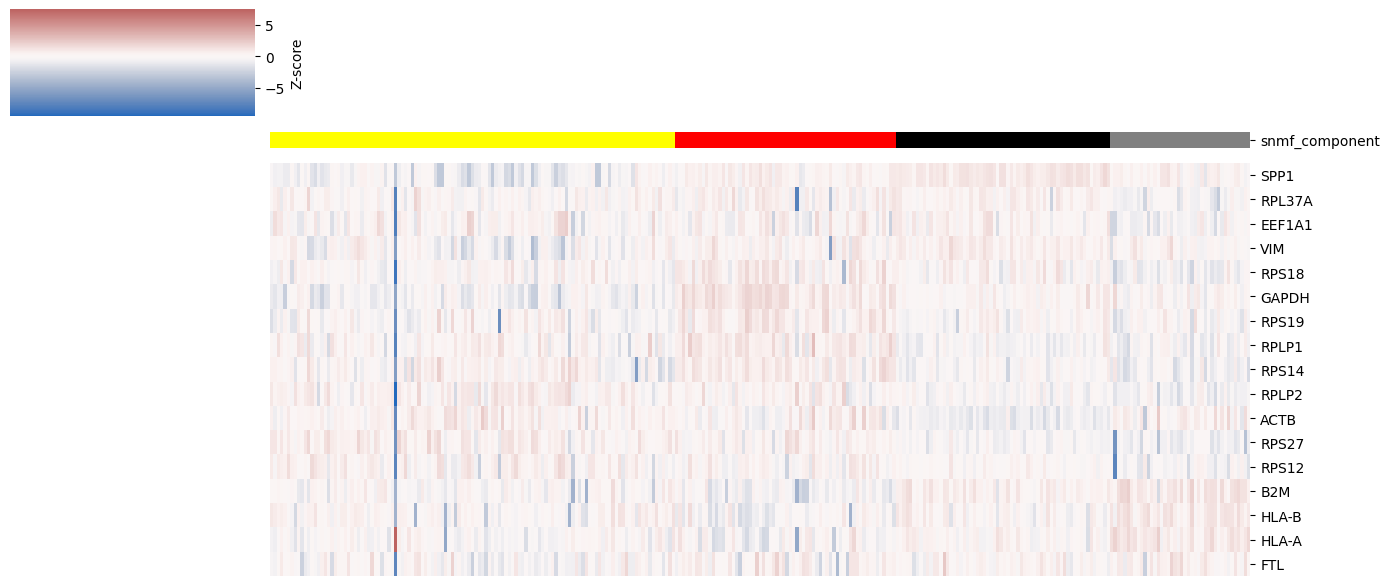

In [23]:
expr = pd.DataFrame(
    adata[:, top_genes_ordered].layers["lognorm"].toarray(),
    index=adata.obs_names,
    columns=top_genes_ordered
).T

spot_order = adata.obs[adata.obs["snmf_component"] != "ambiguous"].sort_values("snmf_component").index
expr = expr[spot_order]

expr_scaled = expr.sub(expr.mean(axis=1), axis=0).div(expr.std(axis=1), axis=0)

cats = adata.obs["snmf_component"].cat.categories
colors = adata.uns["snmf_component_colors"]

lut = dict(zip(cats, colors))

col_colors = adata.obs["snmf_component"].map(lut)

plt.figure(figsize=(14, max(6, len(top_genes_ordered)*0.25)))

g = sns.clustermap(
    expr_scaled,
    row_cluster=False,
    col_cluster=False,
    cmap="vlag",
    center=0,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=expr_scaled.index,
    figsize=(14, max(6, len(top_genes_ordered)*0.25)),
    cbar_kws={"label": "Z-score"}
)

plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

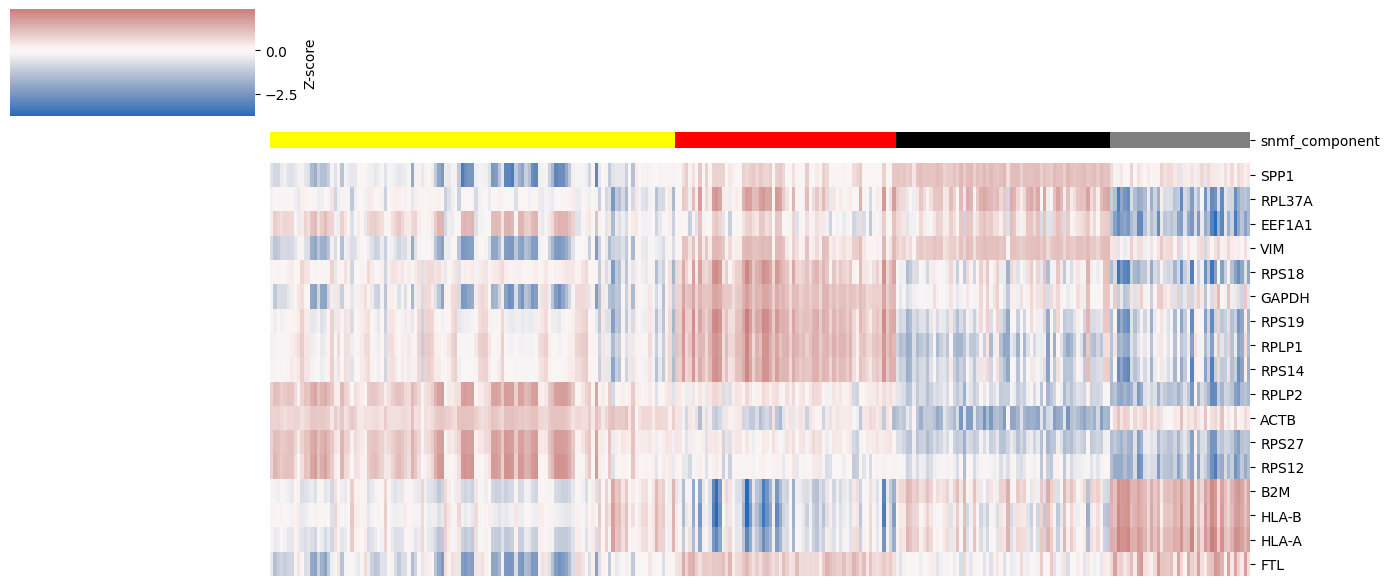

In [24]:
expr = pd.DataFrame(
    adata[:, top_genes_ordered].layers["inferred_lognorm"].toarray(),
    index=adata.obs_names,
    columns=top_genes_ordered
).T

spot_order = adata.obs[adata.obs["snmf_component"] != "ambiguous"].sort_values("snmf_component").index
expr = expr[spot_order]

expr_scaled = expr.sub(expr.mean(axis=1), axis=0).div(expr.std(axis=1), axis=0)

cats = adata.obs["snmf_component"].cat.categories
colors = adata.uns["snmf_component_colors"]

lut = dict(zip(cats, colors))

col_colors = adata.obs["snmf_component"].map(lut)

plt.figure(figsize=(14, max(6, len(top_genes_ordered)*0.25)))

g = sns.clustermap(
    expr_scaled,
    row_cluster=False,
    col_cluster=False,
    cmap="vlag",
    center=0,
    col_colors=col_colors,
    xticklabels=False,
    yticklabels=expr_scaled.index,
    figsize=(14, max(6, len(top_genes_ordered)*0.25)),
    cbar_kws={"label": "Z-score"}
)

plt.tight_layout()
plt.show()

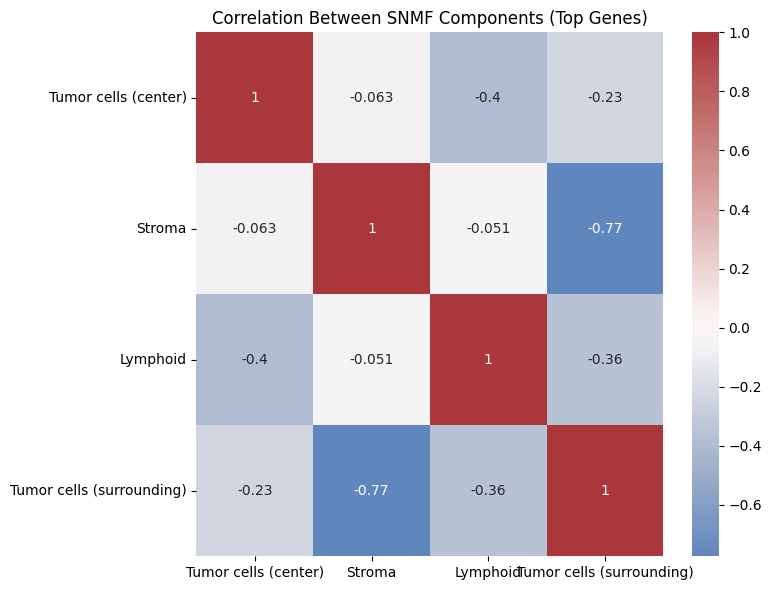

In [25]:
corr_matrix = snmf_scaled.corr()
labels = [annotation.get(c, c) for c in snmf_scaled.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, xticklabels=labels, yticklabels=labels, cmap="vlag", center=0)
plt.title("Correlation Between SNMF Components (Top Genes)")

plt.tight_layout()
plt.savefig(f"plots/K{K}top_genes_corr.png", dpi=300)
plt.savefig(f"plots/K{K}top_genes_corr.pdf", dpi=300)
plt.show()

# Proportions

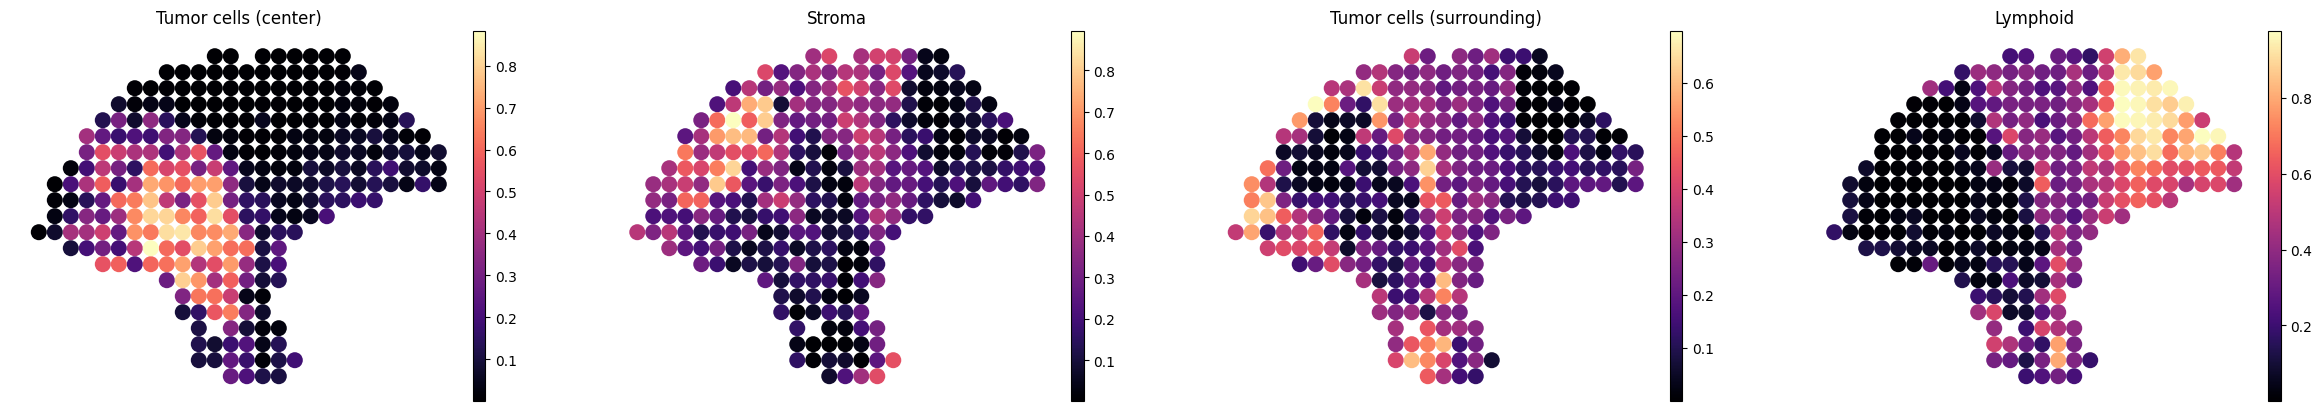

/tmp/ipykernel_1265180/1711416709.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [26]:
colors = annotation.unique().tolist()

fig = sc.pl.spatial(
    adata,
    color=colors,
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=len(colors),
    return_fig=True,
    show=True
)

# Adjust spacing (important when many panels)
fig.tight_layout()

# Save in both formats
fig.savefig(f"plots/K{K}_spatial_plot.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_spatial_plot.pdf", bbox_inches="tight")

plt.close(fig)

# Spatial autocorrelation for each cell type

In [27]:
import squidpy as sq

/scratch/lalonsoeste/envs/ST/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [28]:
sq.gr.spatial_neighbors(
    adata,
    spatial_key="spatial",
    coord_type="generic"
)

# compute Moran's I for every cell-type proportion
sq.gr.spatial_autocorr(
    adata,
    mode="moran",
    genes=SIGNATURES.keys(),
    attr="obs",
    n_perms=1000
)

# results
moran_df = adata.uns["moranI"].copy()
moran_df = moran_df.sort_values("I", ascending=False)

print(moran_df)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 2359.59/s]


                                  I  pval_norm  var_norm  pval_z_sim  \
Lymphoid                   0.861518        0.0  0.001012         0.0   
Tumor cells (center)       0.786226        0.0  0.001012         0.0   
Stroma                     0.663883        0.0  0.001012         0.0   
Tumor cells (surrounding)  0.557482        0.0  0.001012         0.0   

                           pval_sim   var_sim  pval_norm_fdr_bh  \
Lymphoid                   0.000999  0.002879               0.0   
Tumor cells (center)       0.000999  0.002799               0.0   
Stroma                     0.000999  0.002294               0.0   
Tumor cells (surrounding)  0.000999  0.001625               0.0   

                           pval_z_sim_fdr_bh  pval_sim_fdr_bh  
Lymphoid                                 0.0         0.000999  
Tumor cells (center)                     0.0         0.000999  
Stroma                                   0.0         0.000999  
Tumor cells (surrounding)                0.0   

/tmp/ipykernel_1265180/3077171640.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


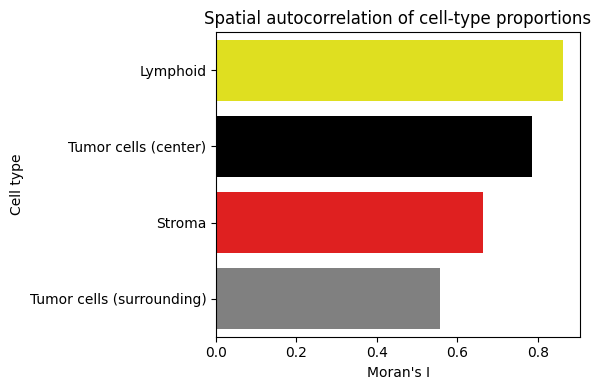

In [29]:
plt.figure(figsize=(6, max(4, 0.3 * len(moran_df))))
sns.barplot(
    data=moran_df.reset_index(),
    y="index",
    x="I",
    palette=PALETTE
)
plt.xlabel("Moran's I")
plt.ylabel("Cell type")
plt.title("Spatial autocorrelation of cell-type proportions")
plt.tight_layout()
plt.show()

# Dispersion analysis with additive factors $\alpha$ and $\beta$

## $\alpha_i$

/tmp/ipykernel_1265180/499333440.py:7: RuntimeWarning: invalid value encountered in log1p
  sns.histplot(np.log1p(alpha), bins=50, kde=True, ax=axes[1])


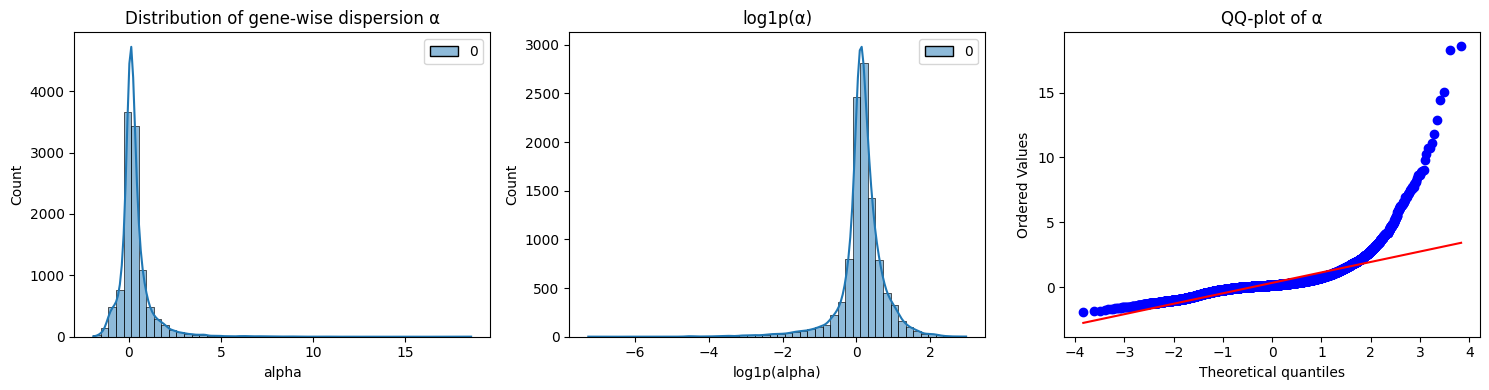

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(alpha, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of gene-wise dispersion α")
axes[0].set_xlabel("alpha")

sns.histplot(np.log1p(alpha), bins=50, kde=True, ax=axes[1])
axes[1].set_title("log1p(α)")
axes[1].set_xlabel("log1p(alpha)")

probplot(alpha.ravel(), dist="norm", plot=axes[2])
axes[2].set_title("QQ-plot of α")

plt.tight_layout()
plt.show()

In [31]:
top_alpha_genes = (
    adata.var[["alpha_dispersion"]]
    .sort_values("alpha_dispersion", ascending=False)
)

top_alpha_genes.head(50).index.tolist()

['NAT6',
 'XRRA1',
 'PVT1',
 'ZNF407',
 'RP11-394O4.5',
 'CYB5D1',
 'CHI3L1',
 'AP001258.4',
 'TBC1D3C',
 'FLT4',
 'TPSB2',
 'CTAGE5',
 'CCDC78',
 'RP11-539L10.3',
 'CASZ1',
 'TPPP3',
 'VMAC',
 'PTGIS',
 'ITK',
 'TREM2',
 'NAIP',
 'CEACAM21',
 'C18orf54',
 'KLHDC1',
 'LINC01588',
 'SNCG',
 'CCL8',
 'DES',
 'DNM1',
 'SPEG',
 'NFAM1',
 'DNALI1',
 'VGLL4',
 'NINL',
 'MAP3K5',
 'LIPE',
 'SSH3',
 'IRX6',
 'SPIN4',
 'COL5A3',
 'RHOBTB1',
 'CCBL2',
 'RRAGB',
 'C20orf96',
 'MON1A',
 'ZC3H8',
 'UVSSA',
 'CHIT1',
 'C3AR1',
 'LAMB3']

### Mean expression vs $\alpha$

/scratch/lalonsoeste/envs/ST/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


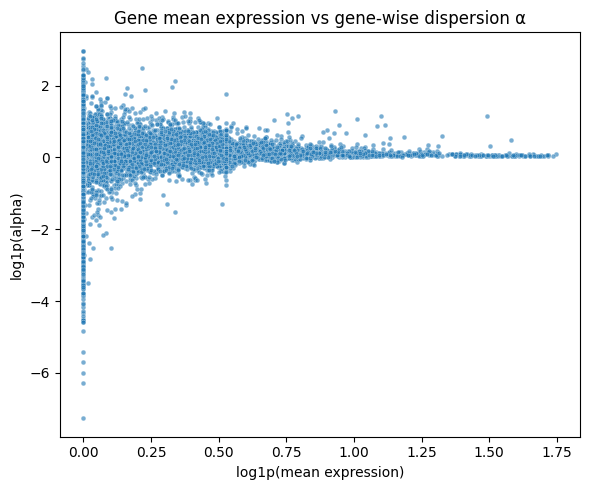

In [32]:
X = adata.X

if sparse.issparse(X):
    gene_mean = np.asarray(X.mean(axis=0)).ravel()
else:
    gene_mean = X.mean(axis=0)

adata.var["mean_expression"] = gene_mean
adata.var["log1p_mean_expression"] = np.log1p(gene_mean)
adata.var["log1p_alpha"] = np.log1p(adata.var["alpha_dispersion"])

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=adata.var,
    x="log1p_mean_expression",
    y="log1p_alpha",
    s=12,
    alpha=0.6
)
plt.xlabel("log1p(mean expression)")
plt.ylabel("log1p(alpha)")
plt.title("Gene mean expression vs gene-wise dispersion α")
plt.tight_layout()
plt.show()

In [33]:
rho, pval = spearmanr(
    adata.var["mean_expression"],
    adata.var["alpha_dispersion"],
    nan_policy="omit"
)

print(f"Spearman correlation mean expression vs alpha: rho={rho:.3f}, p={pval:.3e}")

Spearman correlation mean expression vs alpha: rho=-0.038, p=5.899e-05


**$\alpha$ does not merely track abundance**

### HVGs vs $\alpha$

In [34]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000
)

adata.var["high_alpha"] = False
top_n = 2000
high_alpha_genes = top_alpha_genes.head(top_n).index
adata.var.loc[high_alpha_genes, "high_alpha"] = True

hvg = set(adata.var_names[adata.var["highly_variable"]])
high_alpha = set(high_alpha_genes)

overlap = len(hvg & high_alpha)

print(f"HVG genes: {len(hvg)}")
print(f"High-alpha genes: {len(high_alpha)}")
print(f"Overlap: {overlap}")
print(f"Jaccard index: {overlap / len(hvg | high_alpha):.3f}")

HVG genes: 2000
High-alpha genes: 2000
Overlap: 307
Jaccard index: 0.083


In [35]:
contingency = pd.crosstab(
    adata.var["highly_variable"],
    adata.var["high_alpha"]
)

contingency

high_alpha,False,True
highly_variable,,
False,7249,1693
True,1693,307


In [36]:
oddsratio, pval = fisher_exact(contingency)
print(f"Fisher exact test: odds ratio={oddsratio:.3f}, p={pval:.3e}")

Fisher exact test: odds ratio=0.776, p=1.575e-04


### Spatial maps of genes with higher $\alpha$

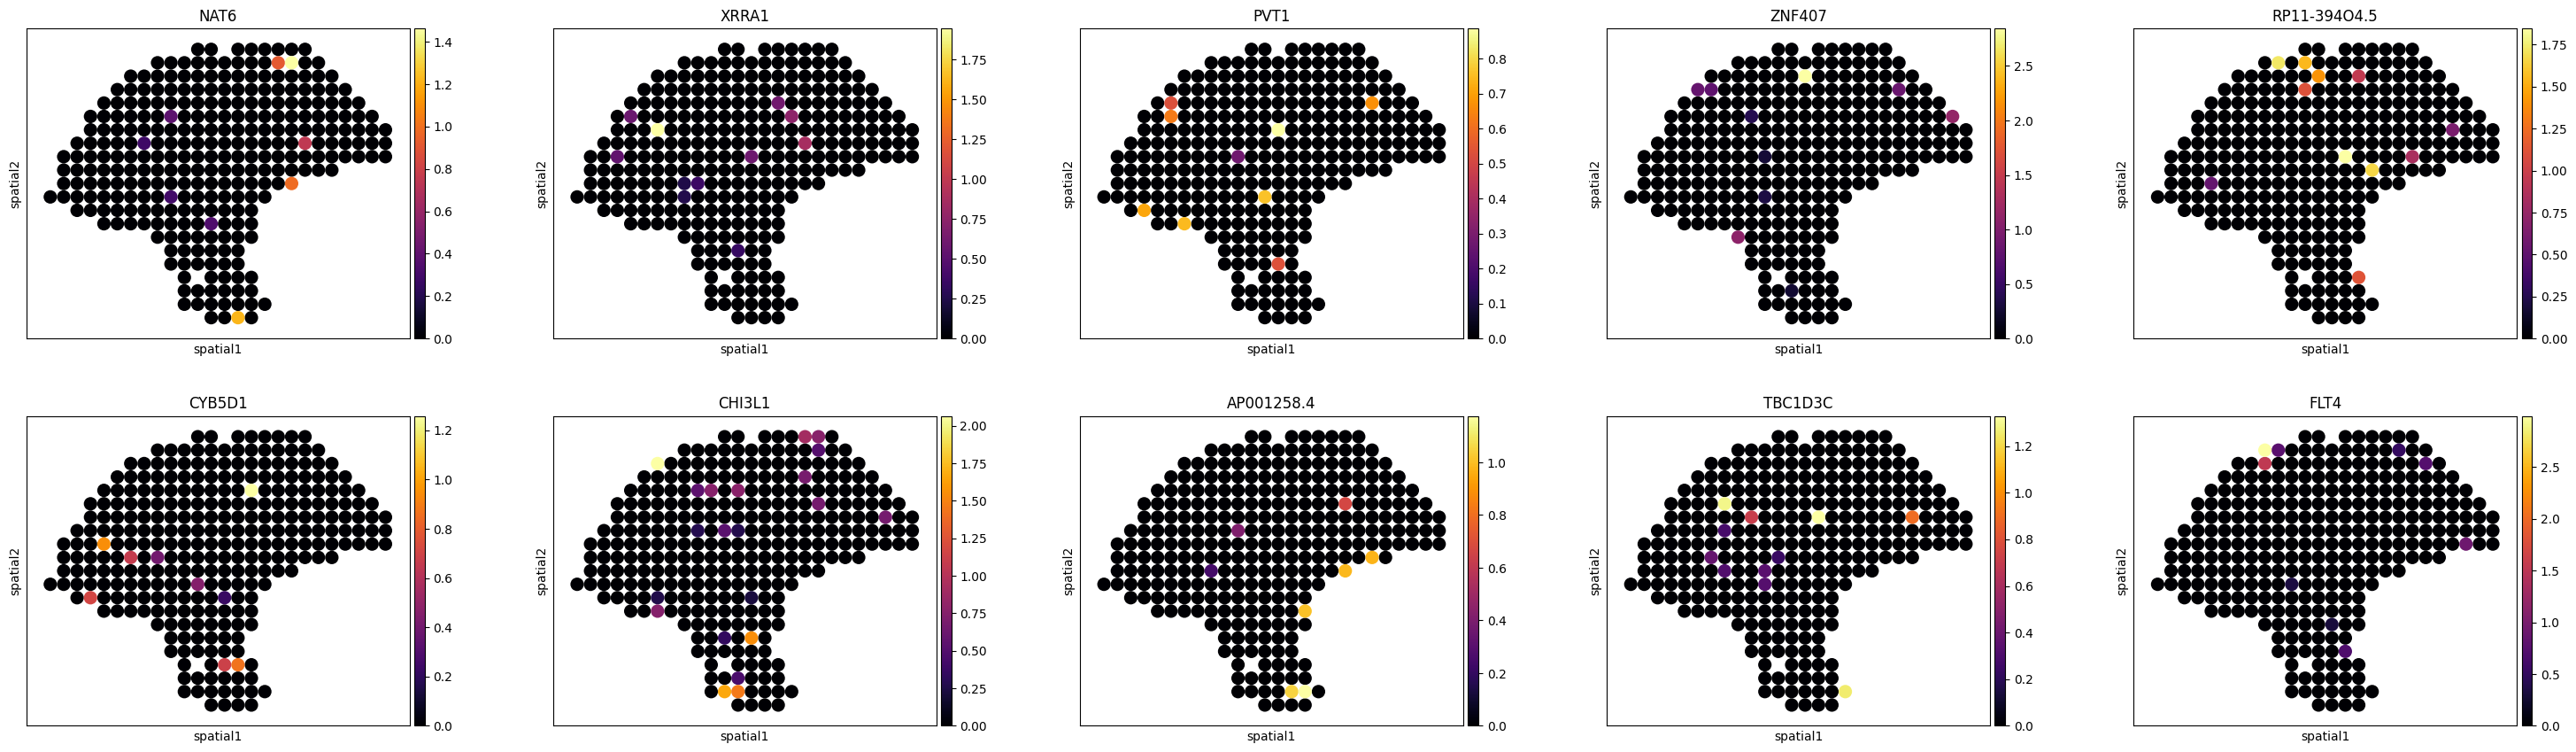

In [37]:
sc.pl.spatial(
    adata,
    color=adata.var["alpha_dispersion"].sort_values(ascending=False).head(10).index,
    cmap="inferno",
    ncols=5,
    spot_size=1,
    layer="lognorm",
)

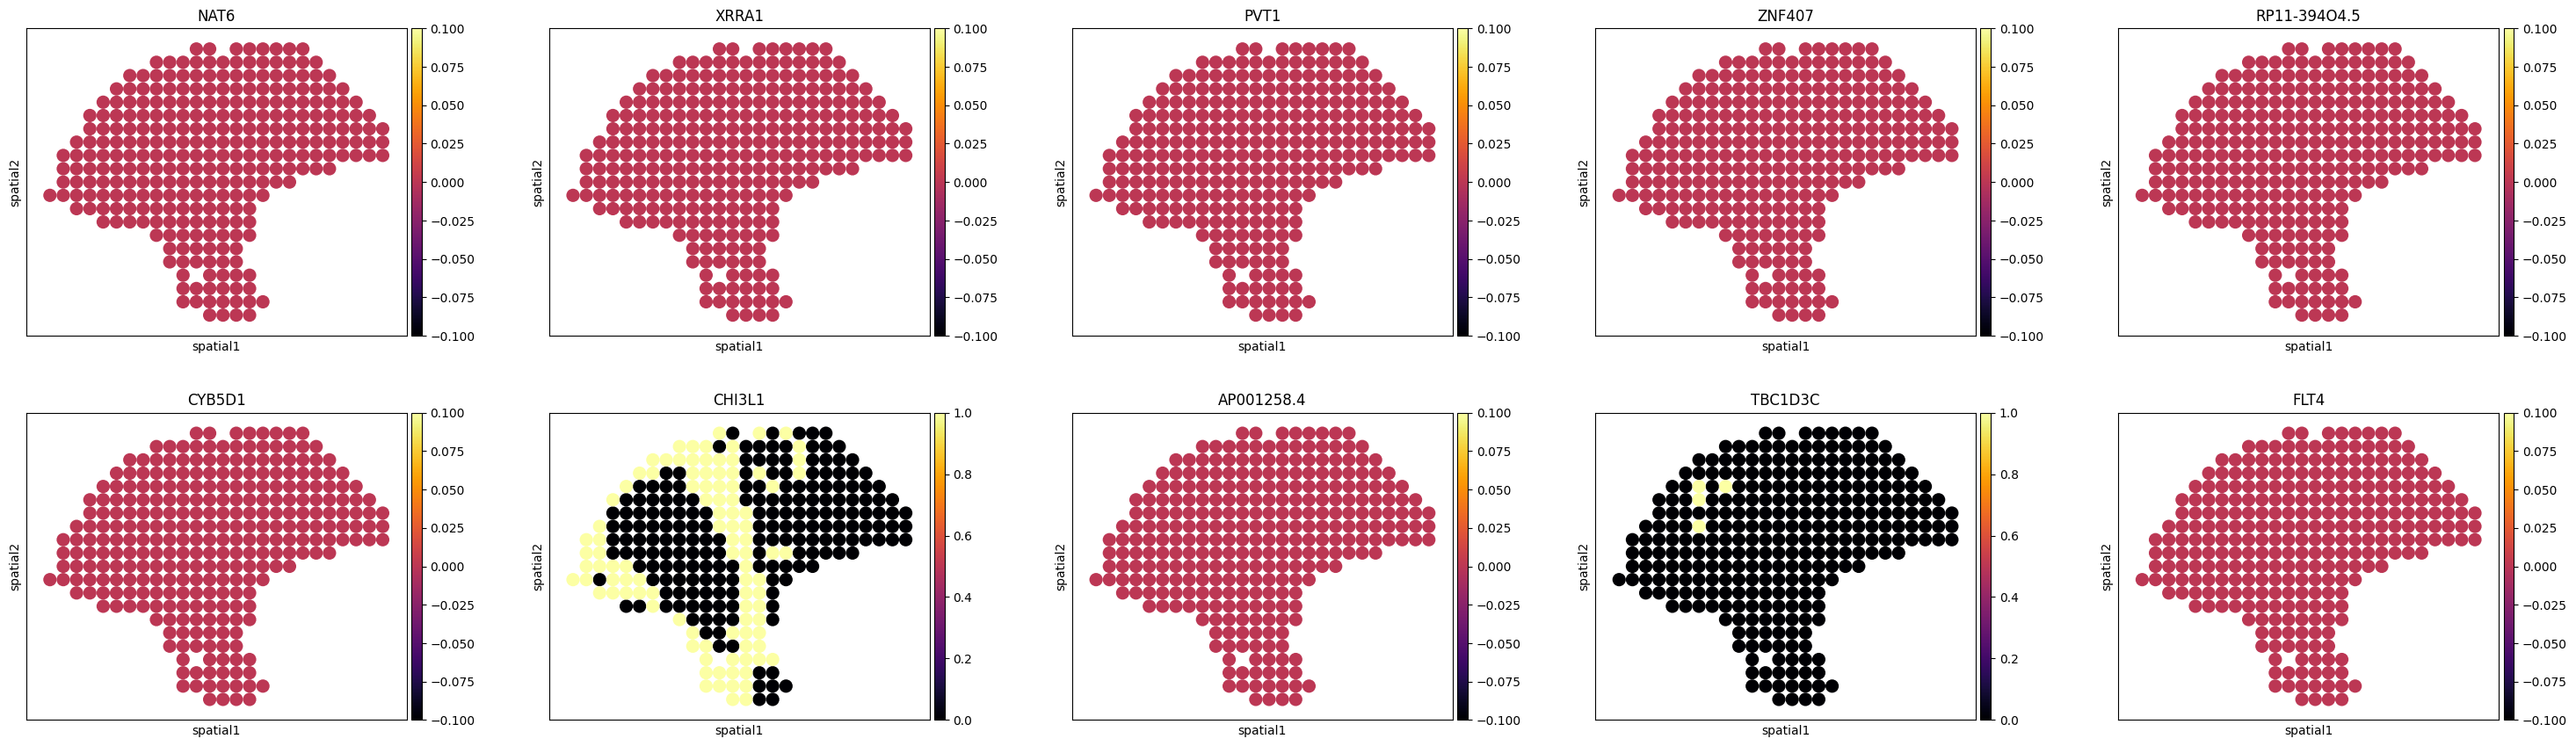

In [38]:
sc.pl.spatial(
    adata,
    color=adata.var["alpha_dispersion"].sort_values(ascending=False).head(10).index,
    cmap="inferno",
    ncols=5,
    spot_size=1,
    layer="inferred_lognorm",
)

### GO enrichment analysis

In [40]:
q = 0.95
alpha_thr = adata.var["alpha_dispersion"].quantile(q)

high_alpha_genes = (
    adata.var_names[adata.var["alpha_dispersion"] >= alpha_thr]
    .astype(str)
    .tolist()
)

background_genes = adata.var_names.astype(str).tolist()

print(f"High-alpha genes: {len(high_alpha_genes)}")
print(f"Background genes: {len(background_genes)}")

High-alpha genes: 548
Background genes: 10942


In [41]:
import gseapy as gp

go_results = gp.enrichr(
    gene_list=high_alpha_genes,
    gene_sets=[
        "GO_Biological_Process_2023",
        "GO_Molecular_Function_2023",
        "GO_Cellular_Component_2023",
    ],
    organism="human",
    background=background_genes,
    outdir=None
)

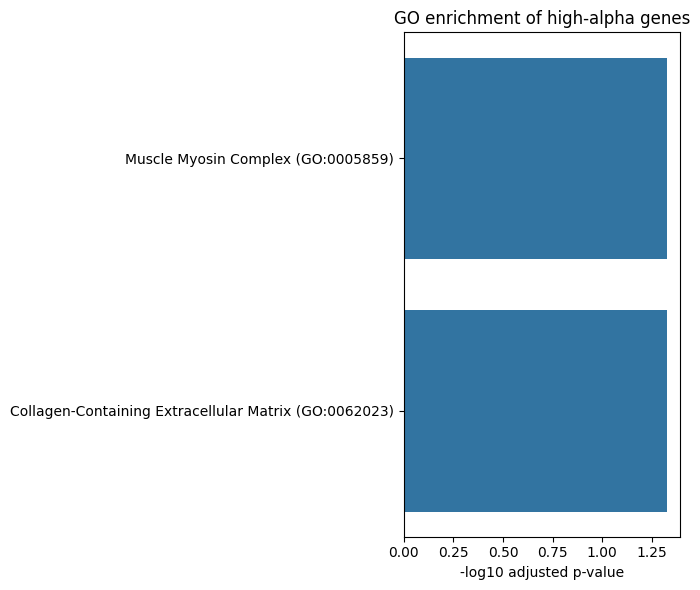

In [42]:
go_df = go_results.results.copy()
sig_go = go_df[go_df["Adjusted P-value"] < 0.05].copy()

top_go = sig_go.head(20).copy()
top_go["minus_log10_fdr"] = -np.log10(top_go["Adjusted P-value"])

plt.figure(figsize=(7, 6))
sns.barplot(
    data=top_go,
    x="minus_log10_fdr",
    y="Term"
)
plt.xlabel("-log10 adjusted p-value")
plt.ylabel("")
plt.title("GO enrichment of high-alpha genes")
plt.tight_layout()
plt.show()

In [43]:
genes = {}

for term in sig_go["Term"].values:
     genes[term] = go_df.loc[
        go_df["Term"] == term,
        "Genes"
    ].iloc[0].split(";")

Muscle Myosin Complex (GO:0005859)


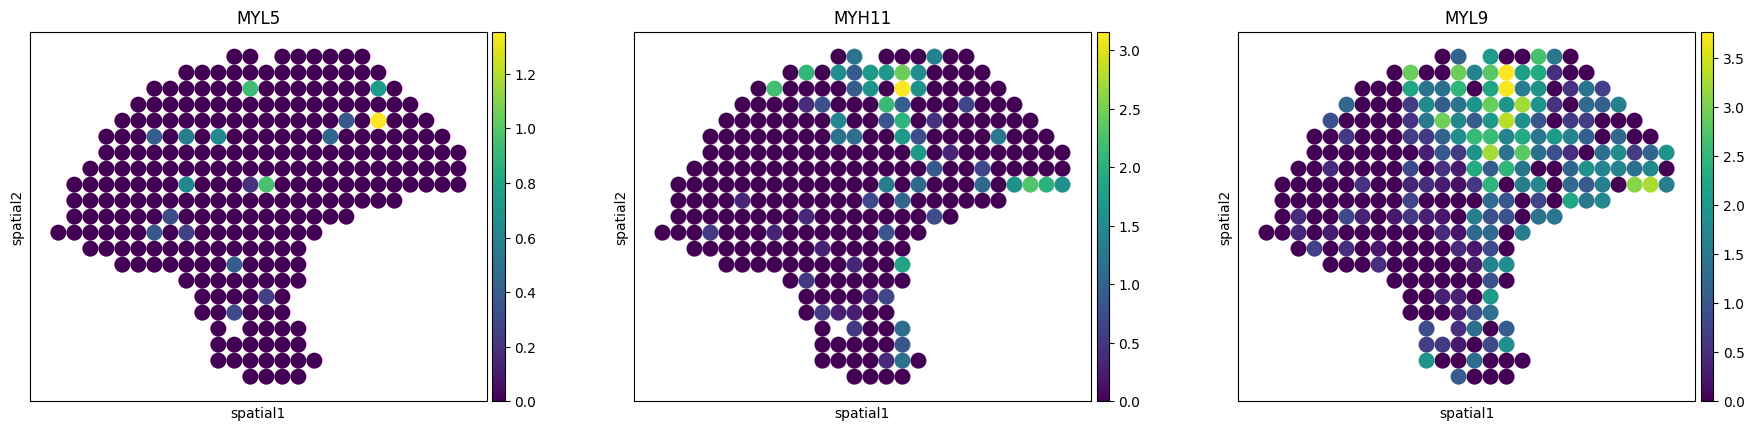

Collagen-Containing Extracellular Matrix (GO:0062023)


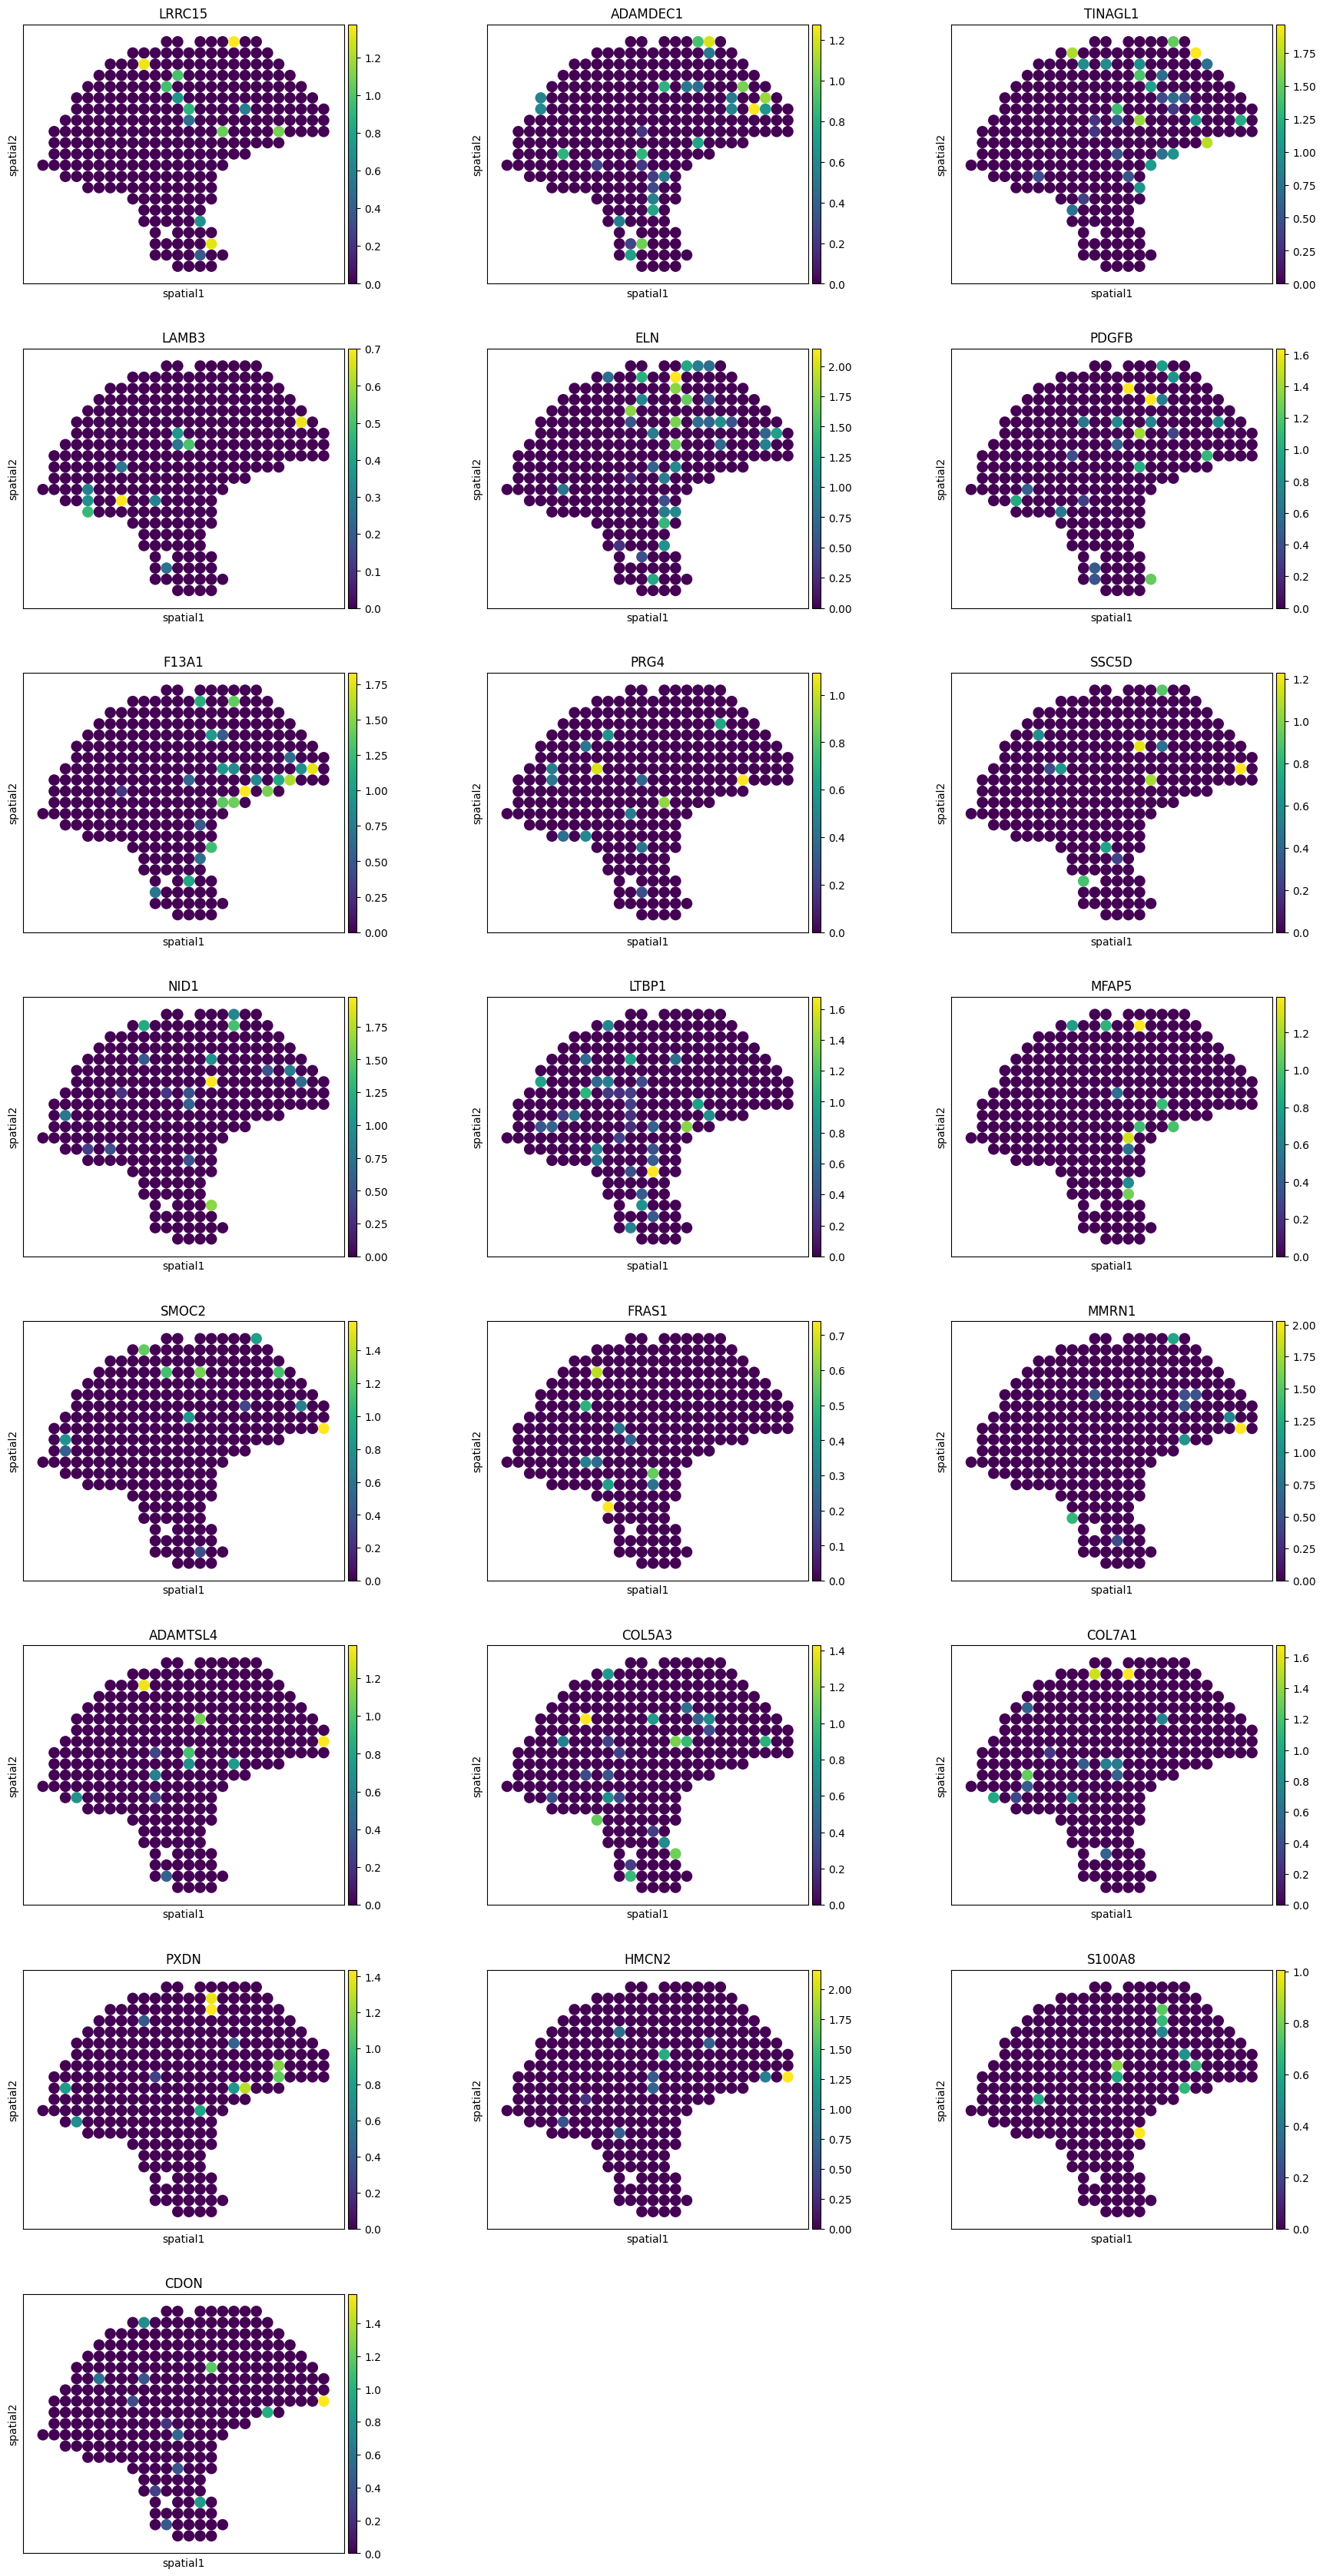

In [44]:
for term, gs in genes.items():

    print(term)

    # keep only genes present in the dataset
    gs = [g for g in gs if g in adata.var_names]

    if len(gs) == 0:
        continue

    fig = sc.pl.spatial(
        adata,
        color=gs,
        cmap="viridis",
        ncols=3,
        spot_size=1,
        return_fig=True,
        layer="lognorm",
    )

The enrichment of the collagen-containing extracellular matrix term is particularly consistent with the biology of metastatic melanoma. Genes such as LRRC15, ELN, LTBP1, MFAP5, NID1, COL5A3, COL7A1, PXDN, and ADAMTSL4 are characteristic of extracellular matrix remodeling, activated fibroblasts, basement membrane organization, and vascular-associated stromal compartments. In stage III melanoma, metastatic invasion into lymph nodes is accompanied by substantial remodeling of the stromal microenvironment through fibroblast activation, collagen deposition, angiogenesis, and extracellular matrix reorganization. These processes are highly localized within the tissue, making them natural candidates for elevated gene-specific dispersion.

The enrichment of the muscle myosin complex initially appears surprising because lymphoid tissue does not contain skeletal muscle. However, the enrichment is driven primarily by MYH11 and MYL9, which are well-established markers of smooth muscle cells, pericytes, vascular-associated cells, and activated myofibroblasts rather than skeletal muscle. These contractile stromal populations are commonly observed around blood vessels and fibrotic regions within metastatic melanoma lesions, indicating that this enrichment likely reflects vascular and stromal remodeling rather than tissue contamination.

Several additional genes reinforce this interpretation. PDGFB is involved in pericyte recruitment and vascular maturation, F13A1 is frequently expressed in activated macrophages and stromal cells, whereas S100A8 and ADAMDEC1 are associated with inflammatory myeloid populations. Together, these genes indicate that the most overdispersed genes participate in processes occurring within spatially restricted stromal and immune niches rather than uniformly across the tissue.

## $\beta_j$

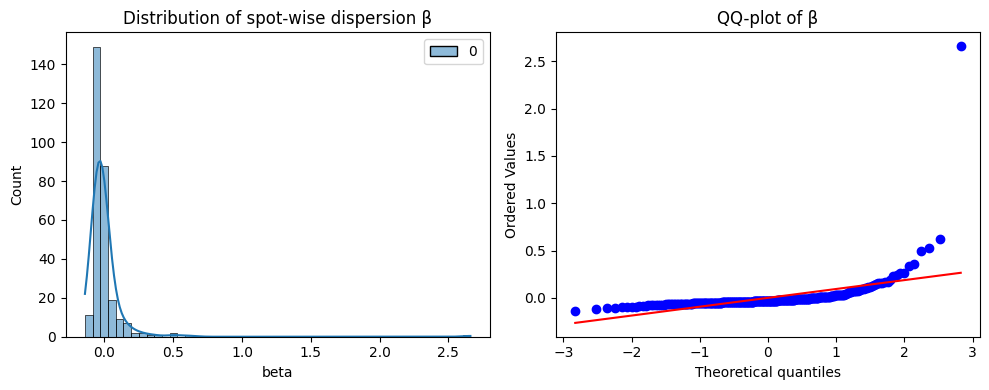

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(beta, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of spot-wise dispersion β")
axes[0].set_xlabel("beta")

probplot(beta.ravel(), dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot of β")

plt.tight_layout()
plt.show()

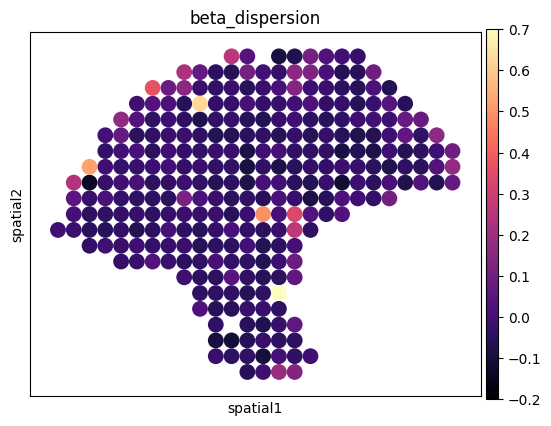

In [64]:
sc.pl.spatial(
    adata,
    color="beta_dispersion",
    spot_size=1,
    cmap="magma",
    vmin=-0.2,
    vmax=0.7 # Avoid outlier making the plot undistinguisable
)

### $\beta$ vs library size

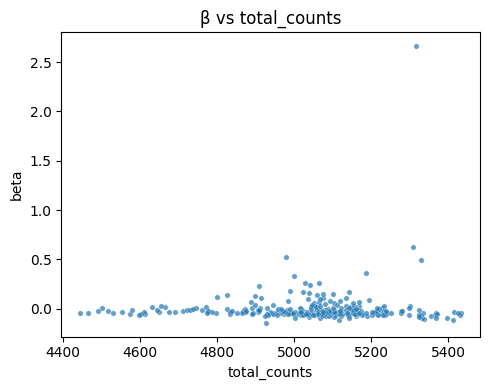

Spearman beta vs total_counts: rho=-0.163, p=5.029e-03


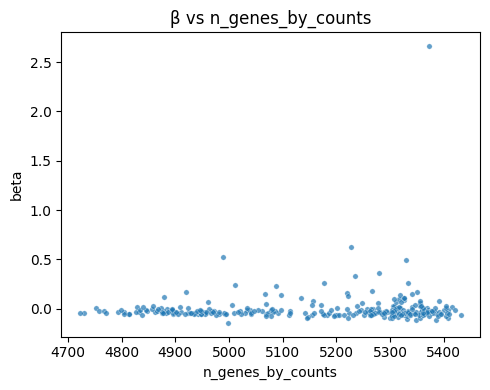

Spearman beta vs n_genes_by_counts: rho=-0.047, p=4.188e-01


In [47]:
# Compute QC metrics if not already present
if "total_counts" not in adata.obs.columns or "n_genes_by_counts" not in adata.obs.columns:
    sc.pp.calculate_qc_metrics(adata, inplace=True)

qc_vars = ["total_counts", "n_genes_by_counts"]

for qc in qc_vars:
    plt.figure(figsize=(5, 4))
    sns.scatterplot(
        data=adata.obs,
        x=qc,
        y="beta_dispersion",
        s=15,
        alpha=0.7
    )
    plt.xlabel(qc)
    plt.ylabel("beta")
    plt.title(f"β vs {qc}")
    plt.tight_layout()
    plt.show()

    rho, pval = spearmanr(
        adata.obs[qc],
        adata.obs["beta_dispersion"],
        nan_policy="omit"
    )

    print(f"Spearman beta vs {qc}: rho={rho:.3f}, p={pval:.3e}")

Negative because we are plotting the inverse dispersion. Still, **this low correlation (-0.163) demonstrates that $\beta$ is not merely technical, but captures biology**

### $\beta$ distribution per cell type

/tmp/ipykernel_1265180/919926148.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


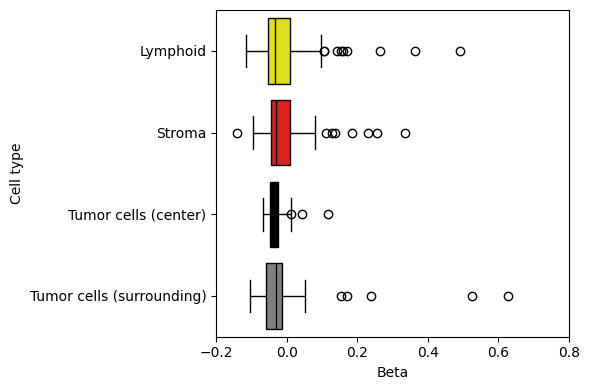

In [67]:
plt.figure(figsize=(6, max(4, 0.3 * len(moran_df))))
ax = sns.boxplot(
    data=adata.obs,
    y="snmf_component",
    x="beta_dispersion",
    palette=PALETTE
)

ax.set_xlim(-0.2, 0.8)

plt.xlabel("Beta")
plt.ylabel("Cell type")
plt.tight_layout()
plt.show()

### $\beta$ enrichment at component boundaries

feature       beta_dispersion
in_median           -0.032164
out_median          -0.034768
p                    0.636864
n_in                      210
n_other                    83
dtype: object
rho boundary vs beta_dispersion: 0.09629262361406456
rho prop-gradient vs beta_dispersion: 0.09938066582002385


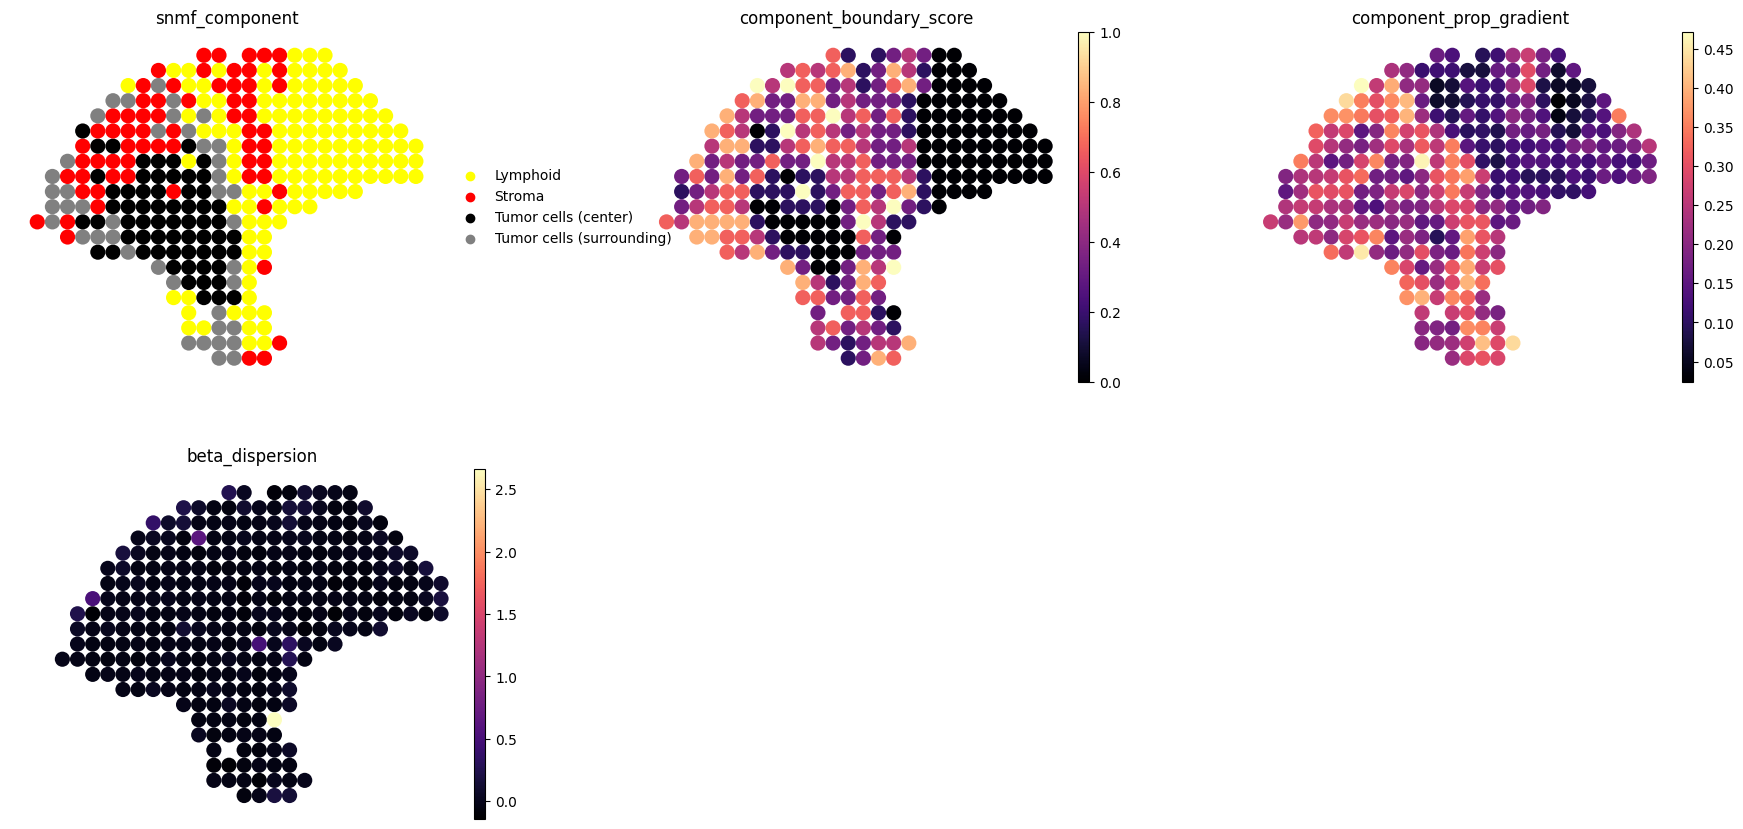

In [49]:
coords = adata.obs[["array_row", "array_col"]].to_numpy() if {"array_row", "array_col"}.issubset(adata.obs.columns) else adata.obsm["spatial"]
tree = cKDTree(coords)
_, nn = tree.query(coords, k=min(7, adata.n_obs))

dominant = adata.obs["snmf_component"].astype(str).to_numpy()
P = snmf_proportions.to_numpy()

boundary_score = []
prop_gradient = []

for i, neigh in enumerate(nn):
    neigh = [j for j in neigh if j != i]
    boundary_score.append(np.mean(dominant[neigh] != dominant[i]))
    prop_gradient.append(np.mean(np.abs(P[neigh] - P[i]).sum(axis=1) / 2))

adata.obs["component_boundary_score"] = boundary_score
adata.obs["component_prop_gradient"] = prop_gradient

boundary_mask = adata.obs["component_boundary_score"] > 0
print(compare_by_mask("beta_dispersion", boundary_mask))
print("rho boundary vs beta_dispersion:", spearmanr(adata.obs["component_boundary_score"], adata.obs["beta_dispersion"]).statistic)
print("rho prop-gradient vs beta_dispersion:", spearmanr(adata.obs["component_prop_gradient"], adata.obs["beta_dispersion"]).statistic)

sc.pl.spatial(
    adata,
    color=["snmf_component", "component_boundary_score", "component_prop_gradient", "beta_dispersion"],
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=3,
    show=False,
)
plt.savefig(f"K{K}_boundary_dispersion.png", dpi=300, bbox_inches="tight")
plt.show()

# Antigen-presentation heterogeneity in tumor-dominant spots

feature       antigen_expr
in_median          2.35476
out_median        2.280856
p                 0.015614
n_in                    74
n_other                219
dtype: object
feature       antigen_beta
in_median         0.117121
out_median        0.130547
p                 0.001558
n_in                    74
n_other                219
dtype: object
rho tumor score vs antigen beta: -0.09364006484355397


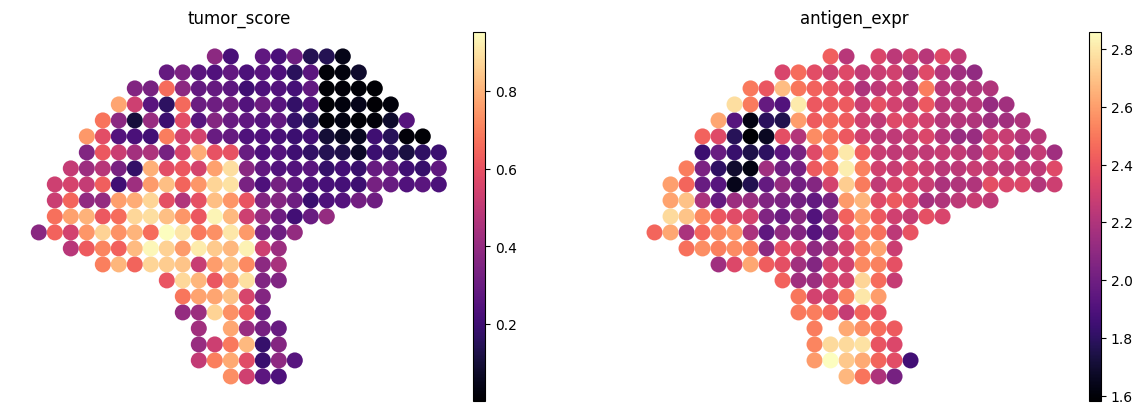

In [81]:
ANTIGEN_GENES = ["B2M", "HLA-A", "HLA-B", "HLA-C", "TAP1", "TAP2", "PSMB8", "PSMB9", "NLRC5"]
ANTIGEN_GENES = ["B2M", "CALR", "NLRC5", "PSMB9", "PSME1", "PSME3", "RFX5", "HSP90AB1"]

add_expr_score(ANTIGEN_GENES, "antigen_expr")
add_phi_score(ANTIGEN_GENES, "antigen_beta")

TUMOR_COMPONENTS = [c for c in SIGNATURES if "Tumor" in c]
adata.obs["tumor_score"] = adata.obs[TUMOR_COMPONENTS].sum(axis=1) if TUMOR_COMPONENTS else 1.0
tumor_mask = adata.obs["tumor_score"] >= adata.obs["tumor_score"].quantile(0.75)

print(compare_by_mask("antigen_expr", tumor_mask))
print(compare_by_mask("antigen_beta", tumor_mask))
print("rho tumor score vs antigen beta:", spearmanr(adata.obs["tumor_score"], adata.obs["antigen_beta"]).statistic)

sc.pl.spatial(
    adata,
    color=["tumor_score", "antigen_expr"],
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=3,
    show=False,
)
plt.savefig(f"K{K}_antigen_presentation_tumor.png", dpi=300, bbox_inches="tight")
plt.show()

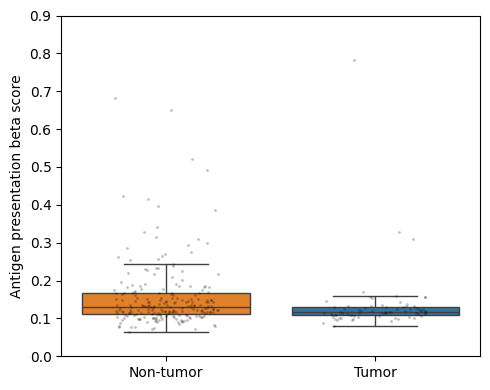

In [83]:
# Label tumor vs non-tumor spots
adata.obs["tumor_group"] = "Non-tumor"
adata.obs.loc[tumor_mask, "tumor_group"] = "Tumor"

# Plot beta values by tumor status
plot_df = adata.obs[["antigen_beta", "tumor_group"]].copy()
plot_df = plot_df.dropna()

plt.figure(figsize=(5, 4))
ax = sns.boxplot(
    data=plot_df,
    x="tumor_group",
    y="antigen_beta",
    hue="tumor_group",
    order=["Non-tumor", "Tumor"],
    showfliers=False,
)

sns.stripplot(
    data=plot_df,
    x="tumor_group",
    y="antigen_beta",
    order=["Non-tumor", "Tumor"],
    color="black",
    alpha=0.25,
    size=2,
    jitter=0.25,
)

ax.set_ylim(0,0.9)

plt.xlabel("")
plt.ylabel("Antigen presentation beta score")
plt.tight_layout()
plt.savefig(f"K{K}_antigen_beta_tumor_vs_nontumor_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

# Transition area

In [51]:
TRANSITION_AREA_EXPRESSED_GENES = ["FTL","B2M","APOE","HLA-A","HLA-B","HLA-C"]

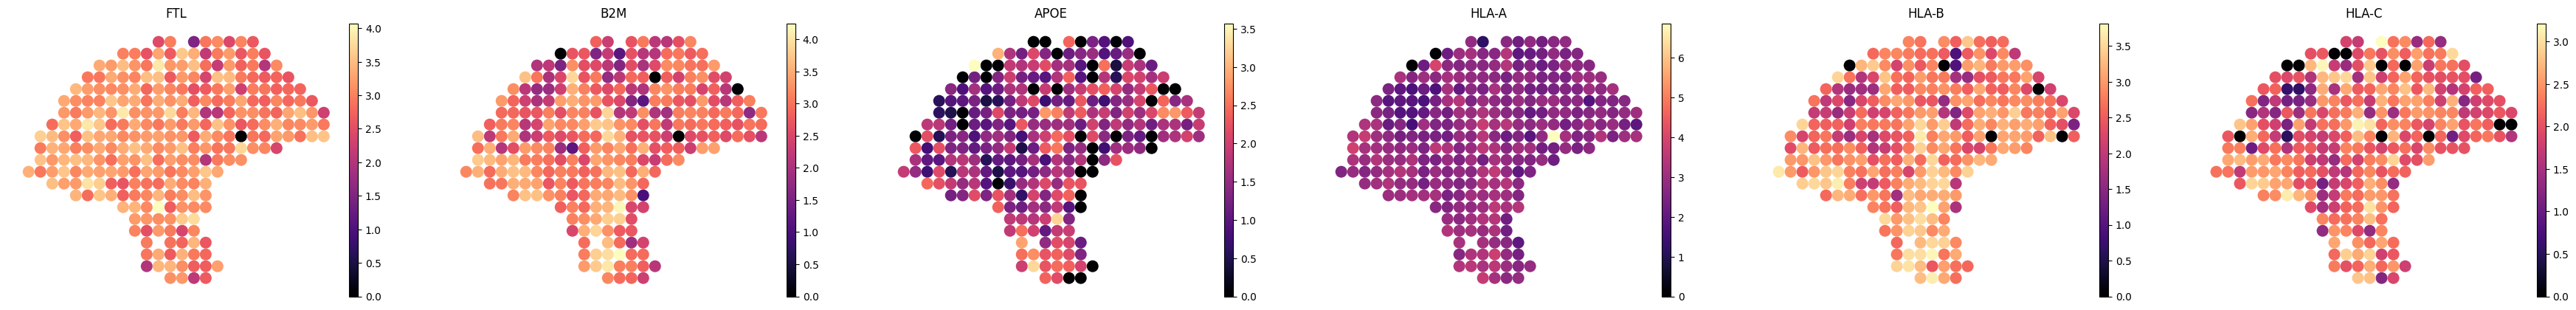

/tmp/ipykernel_1265180/1671442495.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [52]:
fig = sc.pl.spatial(
    adata,
    color=TRANSITION_AREA_EXPRESSED_GENES,
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=len(TRANSITION_AREA_EXPRESSED_GENES),  # all in one row
    return_fig=True,
    show=True,
    layer="lognorm",
)

# Optional: resize to fit many genes
fig.set_size_inches(4 * len(TRANSITION_AREA_EXPRESSED_GENES), 4)
fig.tight_layout()

# Save to PNG and PDF
fig.savefig(f"plots/K{K}_transition_genes_spatial_gt.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_transition_genes_spatial_gt.pdf", bbox_inches="tight")

plt.close(fig)

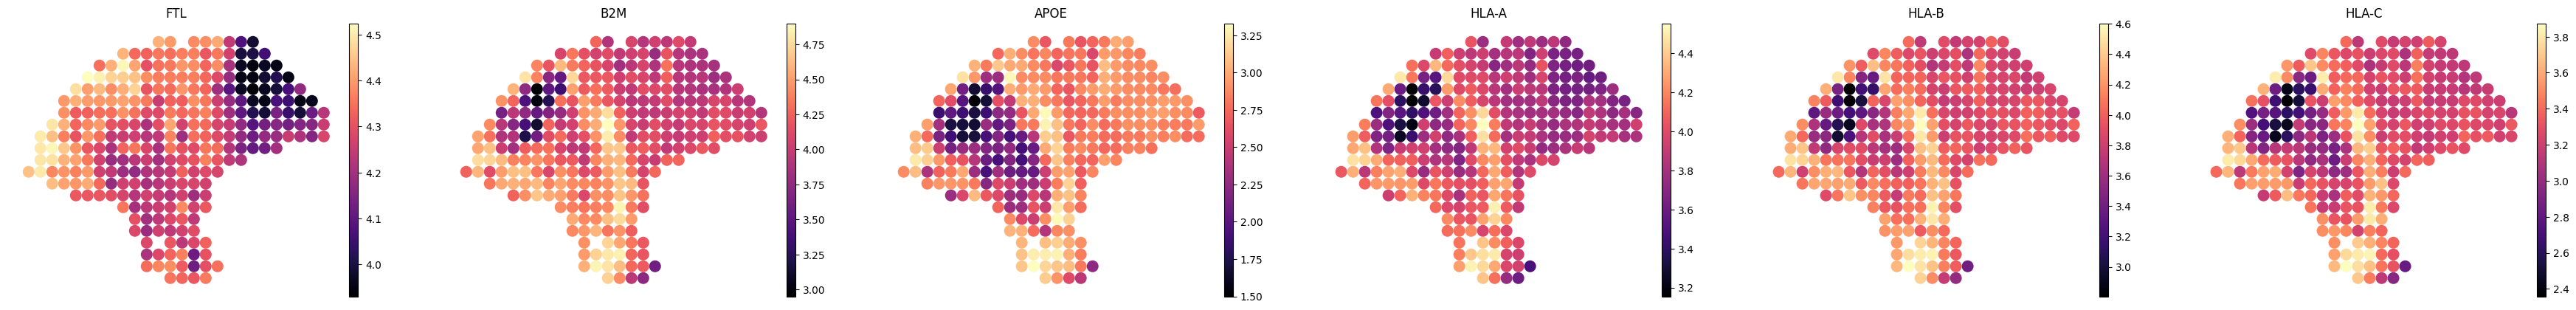

/tmp/ipykernel_1265180/129386336.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


In [53]:
fig = sc.pl.spatial(
    adata,
    color=TRANSITION_AREA_EXPRESSED_GENES,
    spot_size=1,
    frameon=False,
    cmap="magma",
    ncols=len(TRANSITION_AREA_EXPRESSED_GENES),  # all in one row
    return_fig=True,
    show=True
)

# Optional: resize to fit many genes
fig.set_size_inches(4 * len(TRANSITION_AREA_EXPRESSED_GENES), 4)
fig.tight_layout()

# Save to PNG and PDF
fig.savefig(f"plots/K{K}_transition_genes_spatial_inferred.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_transition_genes_spatial_inferred.pdf", bbox_inches="tight")

plt.close(fig)

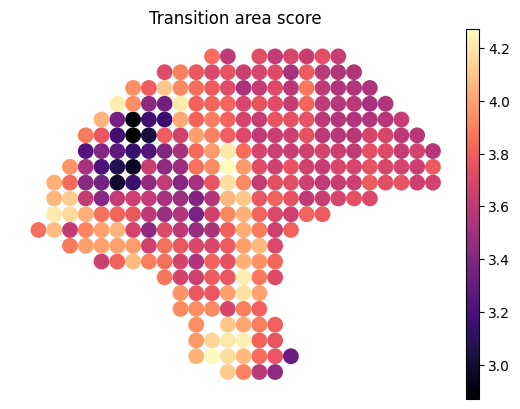

In [54]:
add_expr_score(TRANSITION_AREA_EXPRESSED_GENES, "transition_area_score")

# Plot single spatial score
fig = sc.pl.spatial(
    adata,
    color="transition_area_score",
    spot_size=1,
    frameon=False,
    cmap="magma",
    title="Transition area score",
    return_fig=True,
    show=True
)

# Optional: resize figure for better visibility
fig.set_size_inches(6, 6)
fig.tight_layout()

# Save both PNG and PDF
fig.savefig(f"plots/K{K}_transition_area_score_spatial.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_transition_area_score_spatial.pdf", bbox_inches="tight")

plt.close(fig)

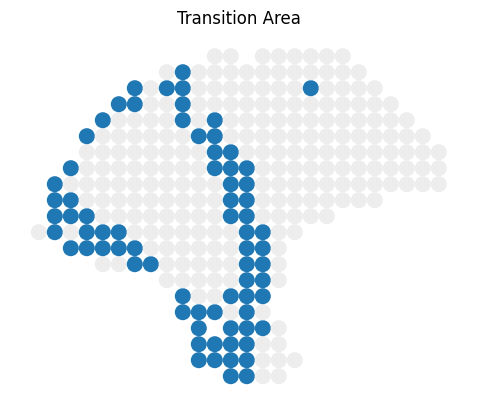

In [55]:
adata.obs["is_in_transition_area"] = np.where(
    adata.obs["transition_area_score"] > adata.obs["transition_area_score"].quantile(0.75),
    "in_transition",
    "out_of_transition"  # use a string instead of None
)

# Optional: make "out_of_transition" white
palette = {
    "in_transition": sns.color_palette("tab20")[0],
    "out_of_transition": "#ededed"
}

fig = sc.pl.spatial(
    adata,
    color="is_in_transition_area",
    spot_size=1,
    frameon=False,
    palette=palette,
    legend_loc="none",
    title="Transition Area",
    return_fig=True,
    show=True
)

# Optional: resize
fig.set_size_inches(6, 6)
fig.tight_layout()

# Save figure
fig.savefig(f"plots/K{K}_transition_area_spatial.png", dpi=300, bbox_inches="tight")
fig.savefig(f"plots/K{K}_transition_area_spatial.pdf", bbox_inches="tight")

plt.close(fig)

In [56]:
for component in SIGNATURES.keys():
    rho, pval = spearmanr(adata.obs.loc[adata.obs["is_in_transition_area"] == "in_transition",component].values, adata.obs.loc[adata.obs["is_in_transition_area"] == "in_transition","transition_area_score"].values)
    print(f"Spearman correlation between '{component}' component and transition area score: {rho:.4f} (pval {pval:.4f})")

Spearman correlation between 'Tumor cells (surrounding)' component and transition area score: 0.8352 (pval 0.0000)
Spearman correlation between 'Tumor cells (center)' component and transition area score: 0.0035 (pval 0.9762)
Spearman correlation between 'Stroma' component and transition area score: -0.3451 (pval 0.0028)
Spearman correlation between 'Lymphoid' component and transition area score: -0.2017 (pval 0.0871)


In [57]:
from scipy.stats import entropy

adata.obs["entropy"] = entropy(snmf_proportions, axis=1)
rho, pval = spearmanr(adata.obs["entropy"].values, adata.obs["transition_area_score"].values)
print(f"Spearman correlation between proportions entropy and transition area: {rho:.4f} (pval {pval:.4f})")

Spearman correlation between proportions entropy and transition area: 0.4420 (pval 0.0000)


# Dispersion-weighted marker discovery

In [58]:
phi_weighted_markers = {}

for comp in SIGNATURES:
    common = snmf_signatures.index.intersection(phi.columns)
    high = adata.obs[comp] >= adata.obs[comp].quantile(0.75)
    low = adata.obs[comp] <= adata.obs[comp].quantile(0.25)

    sig = adata.var.loc[common, comp]
    high_disp = phi.loc[high, common].mean(axis=0)
    low_disp = phi.loc[low, common].mean(axis=0)
    delta_disp = high_disp - low_disp

    tbl = pd.DataFrame({
        "gene": common,
        "component": comp,
        "signature_loading": sig.values,
        "mean_disp_high_component": high_disp.values,
        "mean_disp_low_component": low_disp.values,
        "delta_dispersion": delta_disp.values,
    }).set_index("gene")

    tbl["dispersion_weighted_score"] = zscore(tbl["signature_loading"]) + zscore(tbl["delta_dispersion"])
    tbl = tbl.sort_values("dispersion_weighted_score", ascending=False)

    phi_weighted_markers[comp] = tbl
    print("\n", comp)
    display(tbl.head(20))

all_dispersion_weighted_markers = pd.concat(phi_weighted_markers.values())
all_dispersion_weighted_markers.to_csv(f"K{K}_dispersion_weighted_markers.csv")


 Tumor cells (surrounding)


,component,signature_loading,mean_disp_high_component,mean_disp_low_component,delta_dispersion,dispersion_weighted_score
gene,,,,,,
B2M,Tumor cells (surrounding),158.284709,0.139499,0.066653,0.072846,41.989422
ACTB,Tumor cells (surrounding),123.794645,0.108705,0.033992,0.074713,33.010795
HLA-B,Tumor cells (surrounding),119.286658,0.135630,0.062608,0.073022,31.708618
HLA-A,Tumor cells (surrounding),112.643249,0.113432,0.039099,0.074333,30.042454
FTL,Tumor cells (surrounding),81.914503,0.135759,0.062745,0.073014,21.844733
IGLL5,Tumor cells (surrounding),69.887042,2.254111,2.182025,0.072086,18.608723
GAPDH,Tumor cells (surrounding),60.942886,0.140055,0.067225,0.072830,16.297586
HLA-C,Tumor cells (surrounding),57.789856,0.112988,0.038626,0.074362,15.567265
VIM,Tumor cells (surrounding),51.298558,0.119514,0.045608,0.073905,13.823708



 Tumor cells (center)


,component,signature_loading,mean_disp_high_component,mean_disp_low_component,delta_dispersion,dispersion_weighted_score
gene,,,,,,
SPP1,Tumor cells (center),122.098203,0.043919,0.137762,-0.093843,23.639978
RPL37A,Tumor cells (center),103.774031,0.017511,0.111498,-0.093987,19.959007
EEF1A1,Tumor cells (center),99.279740,0.032494,0.126413,-0.093919,19.060584
VIM,Tumor cells (center),92.186145,0.037995,0.131842,-0.093848,17.640994
RPS18,Tumor cells (center),91.130480,0.022926,0.117059,-0.094133,17.417146
RPLP2,Tumor cells (center),90.751562,0.012125,0.104908,-0.092783,17.398620
TPT1,Tumor cells (center),90.291775,0.022955,0.117088,-0.094132,17.248984
RPS21,Tumor cells (center),84.214656,0.018457,0.112556,-0.094099,16.031649
RPS12,Tumor cells (center),80.488158,0.013661,0.106908,-0.093247,15.320568



 Stroma


,component,signature_loading,mean_disp_high_component,mean_disp_low_component,delta_dispersion,dispersion_weighted_score
gene,,,,,,
GAPDH,Stroma,392.775309,0.104257,0.102902,0.001355,43.940800
RPS19,Stroma,210.614862,0.075219,0.076193,-0.000974,23.622180
RPLP1,Stroma,208.518677,0.075968,0.076822,-0.000855,23.399231
RPS18,Stroma,185.923769,0.068122,0.070996,-0.002874,20.750235
RPS14,Stroma,173.638823,0.070567,0.072654,-0.002087,19.450123
RPL13A,Stroma,168.178613,0.059274,0.065356,-0.006082,18.549201
RPL13,Stroma,166.635501,0.057789,0.064528,-0.006739,18.329646
RPS21,Stroma,151.249307,0.063515,0.067952,-0.004438,16.799238
RPLP2,Stroma,152.915255,0.055785,0.063465,-0.007679,16.742368



 Lymphoid


,component,signature_loading,mean_disp_high_component,mean_disp_low_component,delta_dispersion,dispersion_weighted_score
gene,,,,,,
RPLP2,Lymphoid,144.675276,0.061210,0.021569,0.039641,27.729041
ACTB,Lymphoid,133.920514,0.072592,0.036355,0.036236,24.781136
RPS27,Lymphoid,115.700111,0.069465,0.032110,0.037355,21.826770
RPS12,Lymphoid,109.749818,0.062725,0.023314,0.039411,21.362849
RPL13,Lymphoid,97.509800,0.062724,0.023313,0.039411,19.155697
RPS18,Lymphoid,98.142066,0.070532,0.033583,0.036949,18.540408
RPS27A,Lymphoid,95.634434,0.066433,0.027999,0.038434,18.527982
RPL13A,Lymphoid,93.723693,0.063800,0.024657,0.039142,18.393231
EEF1A1,Lymphoid,99.684280,0.078462,0.043558,0.034904,18.212912


# Dispersion analysis: how much by spot variance $\beta_j$ and how much by gene variance $\alpha_i$

In [85]:
alpha = alpha[np.isfinite(alpha)]
beta = beta[np.isfinite(beta)]

var_alpha = np.var(alpha, ddof=1)
var_beta = np.var(beta, ddof=1)
var_total = var_alpha + var_beta

gene_fraction = var_alpha / var_total
spot_fraction = var_beta / var_total

dispersion_decomposition = pd.DataFrame({
    "component": ["Gene effect α", "Spot effect β"],
    "variance": [var_alpha, var_beta],
    "fraction": [gene_fraction, spot_fraction],
    "percentage": [100 * gene_fraction, 100 * spot_fraction]
})

dispersion_decomposition

,component,variance,fraction,percentage
0,Gene effect α,0.979225,0.968358,96.835831
1,Spot effect β,0.031997,0.031642,3.164169


In [108]:
X = adata.layers["counts"]
Mu = adata.layers["inferred_counts"]

eps = 1e-10

Mu = np.maximum(Mu, eps)
Phi = np.maximum(phi, eps)

Var = Mu + Phi * Mu**2

pearson_residuals = (X - Mu) / np.sqrt(Var).to_numpy()

print(np.mean(pearson_residuals, axis=None))
print(np.var(pearson_residuals, axis=None))

-0.45222274748990277
0.5539348703084838


In [106]:
abs_res = np.abs(pearson_residuals)

print(np.quantile(pearson_residuals, [0, .001, .01, .5, .99, .999, 1]))
print("Number > 100:", np.sum(abs_res > 100))
print("Number > 1000:", np.sum(abs_res > 1000))

[-1.34720877e+01 -4.47952735e+00 -2.04834230e+00 -1.00000000e-05
  1.00000000e+05  2.00000000e+05  7.00000000e+05]
Number > 100: 146377
Number > 1000: 146377
